# Cycle 1 — Modelling: Match Outcome Prediction (Win / Draw / Loss)

**Project:** Football Predictor  
**Inputs:** `data/processed/premier_league_matches_processed.csv` 
**Depends on:** All exploration, preprocessing, and feature engineering notebooks

---

## Purpose of this Notebook

This notebook trains and evaluates machine learning models for predicting Premier League match outcomes (Home Win / Draw / Away Win).


## Model Progression

We train 5 models in increasing complexity:

| Model | Why we use it |
|---|---|
| **Dummy Classifier** | Always predicts the most common class (Home Win). Sets the floor — any real model must beat this |
| **Logistic Regression** | Simple, interpretable linear model. Fast baseline for structured data |
| **Random Forest** | Ensemble of decision trees. Handles non-linear patterns, robust to noise |
| **XGBoost** | Gradient boosting. Generally highest accuracy for tabular data |
| **LightGBM** | Gradient boosting optimized for speed and memory. Uses leaf‑wise growth, histogram splitting, and native categorical support — often faster than XGBoost on large datasets |


In [40]:
import sys, os

# Locate project root (folder containing data/, models/, notebooks/)
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, 'data')):
    _p = os.path.dirname(_here)
    if _p == _here: raise RuntimeError('project root not found')
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)

from config import Paths, ensure_dirs
ensure_dirs()  # creates models/cycle1-3 if missing

import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier

print('All libraries imported successfully')

All libraries imported successfully


## Load and Prepare Data

**What it does:** Loads the processed dataset, separates features (X) from target (y), and splits into train/test sets.

**Why:** The 80/20 train/test split is standard. `random_state=42` ensures reproducibility — running this again gives the same split.

In [32]:
df1 = pd.read_csv(str(Paths.PL_MATCHES_PROCESSED))

X1 = df1.drop(columns=['FTR', 'Season'])  # Season is meta (year), not a feature
y1 = df1['FTR']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# Scale features for Logistic Regression
scaler1 = StandardScaler()
X1_train_s = scaler1.fit_transform(X1_train)
X1_test_s  = scaler1.transform(X1_test)

print('Total rows:', len(df1))
print('Features:', X1.shape[1])
print('Training rows:', len(X1_train))
print('Test rows:', len(X1_test))
print()
print('Target distribution (full dataset):')
print(y1.value_counts().sort_index())
print('(0=Away Win, 1=Draw, 2=Home Win)')

Total rows: 6840
Features: 33
Training rows: 5472
Test rows: 1368

Target distribution (full dataset):
FTR
0    1913
1    1751
2    3176
Name: count, dtype: int64
(0=Away Win, 1=Draw, 2=Home Win)


### Observations
- Class imbalance: Home wins are almost twice as common as draws
- A dummy model always predicting Home Win would score ~46.4% — this is the floor to beat
- StandardScaler fitted on training data only, then applied to test — prevents data leakage from scaling

## Model 1: Dummy Classifier

**What it does:** Always predicts the most frequent class (Home Win). No learning involved.

**Why:** Establishes the absolute minimum baseline. If a real model cannot beat this, it has learned nothing useful.

**Comparison with FinalYearProject:** Same model used. FYP Dummy got ~38.55% (on a different, smaller dataset). Here the baseline is higher (~46%) because Home Wins are more frequent in this larger dataset.

In [33]:
dummy1 = DummyClassifier(strategy='most_frequent', random_state=42)
dummy1.fit(X1_train, y1_train)
y_pred_dummy1 = dummy1.predict(X1_test)

print('DUMMY CLASSIFIER')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_dummy1):.4f} ({accuracy_score(y1_test, y_pred_dummy1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_dummy1, target_names=['Away Win', 'Draw', 'Home Win']))

DUMMY CLASSIFIER
Accuracy: 0.4635 (46.35%)

              precision    recall  f1-score   support

    Away Win       0.00      0.00      0.00       394
        Draw       0.00      0.00      0.00       340
    Home Win       0.46      1.00      0.63       634

    accuracy                           0.46      1368
   macro avg       0.15      0.33      0.21      1368
weighted avg       0.21      0.46      0.29      1368



### Observations
- Accuracy: **46.35%** — this is the floor
- Predicts Home Win for every match — recall 1.00 for Home Win, 0 for the other classes
- Away Win and Draw are completely ignored — precision and recall both 0
- This reflects the class imbalance: Home Win (46.4% of training data) is the safe default guess

### Notes for Report
- A baseline of 46.35% means we need to significantly exceed this to claim the model is learning anything
- Draw prediction is the hardest class — all models struggle here

## Model 2: Logistic Regression

**What it does:** Fits a linear decision boundary between classes. Simple, fast, and interpretable.

**Why:** The first real ML model in the progression. If Logistic Regression already beats the dummy by a meaningful margin, the features contain real signal.

**`class_weight='balanced'`:** Adjusts for class imbalance automatically — gives more weight to minority classes (Draw, Away Win) during training.

In [34]:
lr1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr1.fit(X1_train_s, y1_train)
y_pred_lr1 = lr1.predict(X1_test_s)

print('LOGISTIC REGRESSION')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_lr1):.4f} ({accuracy_score(y1_test, y_pred_lr1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_lr1, target_names=['Away Win', 'Draw', 'Home Win']))

LOGISTIC REGRESSION
Accuracy: 0.4985 (49.85%)

              precision    recall  f1-score   support

    Away Win       0.46      0.59      0.52       394
        Draw       0.30      0.25      0.27       340
    Home Win       0.64      0.57      0.60       634

    accuracy                           0.50      1368
   macro avg       0.46      0.47      0.46      1368
weighted avg       0.50      0.50      0.50      1368



### Observations
- Accuracy: **49.85%** — beats the dummy by **3.50 percentage points**
- Now predicting all 3 classes — the model is actually learning
- Home Win: best precision (0.64) — model is fairly confident when it predicts a home win
- Draw: worst performance (f1 = 0.27) — draws are genuinely difficult to predict
- Away Win: good recall (0.59) — catches roughly 60% of actual away wins

### Notes for Report
- Logistic Regression beats the dummy, confirming the features have predictive signal
- Draw prediction difficulty is a known challenge in football analytics

## Model 3: Random Forest

**What it does:** Trains 100 decision trees on random subsets of data and features, then aggregates their predictions.

**Why:** Handles non-linear relationships that Logistic Regression cannot. More powerful than a single decision tree because averaging 100 trees reduces overfitting.

In [35]:
rf1 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf1.fit(X1_train, y1_train)
y_pred_rf1 = rf1.predict(X1_test)

print('RANDOM FOREST')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_rf1):.4f} ({accuracy_score(y1_test, y_pred_rf1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_rf1, target_names=['Away Win', 'Draw', 'Home Win']))

RANDOM FOREST
Accuracy: 0.5139 (51.39%)

              precision    recall  f1-score   support

    Away Win       0.50      0.42      0.45       394
        Draw       0.28      0.10      0.14       340
    Home Win       0.55      0.80      0.65       634

    accuracy                           0.51      1368
   macro avg       0.44      0.44      0.42      1368
weighted avg       0.47      0.51      0.47      1368



### Observations
- Accuracy: **51.39%** — beats Logistic Regression by **1.54 percentage points**
- Home Win recall is high (0.80) — very good at identifying home wins
- Draw recall drops to **0.10** — the model barely predicts draws at all
- Random Forest leans towards the majority class despite `balanced` weights — the gain over LR comes from majority-class precision, not from learning draws

### Notes for Report
- The progression Dummy → LogReg → RF (46% → 50% → 51%) shows consistent improvement
- Draw prediction remains the weakest point — a pattern across all models

## Model 4: XGBoost

**What it does:** Gradient boosting — builds trees sequentially, each one correcting the errors of the previous. Generally the strongest performer on tabular data.

**Why:** The most powerful model in the progression. In FinalYearProject, XGBoost Tuned achieved 50.92% — but on leakage-contaminated data. Here we see what XGBoost achieves on clean data.

In [36]:
xgb1 = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0)
xgb1.fit(X1_train, y1_train)
y_pred_xgb1 = xgb1.predict(X1_test)

print('XGBOOST')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_xgb1):.4f} ({accuracy_score(y1_test, y_pred_xgb1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_xgb1, target_names=['Away Win', 'Draw', 'Home Win']))

XGBOOST
Accuracy: 0.5095 (50.95%)

              precision    recall  f1-score   support

    Away Win       0.47      0.43      0.45       394
        Draw       0.34      0.20      0.25       340
    Home Win       0.57      0.73      0.64       634

    accuracy                           0.51      1368
   macro avg       0.46      0.45      0.45      1368
weighted avg       0.48      0.51      0.49      1368



### Observations
- Accuracy: **50.95%** — slightly below Random Forest (51.39%) without tuning
- Better draw prediction than Random Forest (recall **0.20 vs 0.10**)
- XGBoost is more balanced across all three classes
- With hyperparameter tuning, XGBoost typically surpasses Random Forest

### Notes for Report
- XGBoost without tuning is not always the best — it needs tuning to shine
- The untuned XGBoost still beats the dummy by ~4.6 percentage points
- Tuning is the natural next step (Cycle 2)

## Model 5: LightGBM

In [37]:
lgb1 = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
lgb1.fit(X1_train, y1_train)
y_pred_lgb1 = lgb1.predict(X1_test)

print('LIGHTGBM')
print(f'Accuracy: {accuracy_score(y1_test, y_pred_lgb1):.4f} ({accuracy_score(y1_test, y_pred_lgb1)*100:.2f}%)')
print()
print(classification_report(y1_test, y_pred_lgb1, target_names=['Away Win', 'Draw', 'Home Win']))

LIGHTGBM
Accuracy: 0.5402 (54.02%)

              precision    recall  f1-score   support

    Away Win       0.54      0.44      0.49       394
        Draw       0.34      0.18      0.23       340
    Home Win       0.58      0.79      0.67       634

    accuracy                           0.54      1368
   macro avg       0.49      0.47      0.46      1368
weighted avg       0.51      0.54      0.51      1368



## Results Summary

**What it does:** Summarises all model results on Dataset 1 in one table.

**Why:** Easy to compare all models at a glance and identify the best performer.

In [39]:
results_d1 = pd.DataFrame({
    'Model': ['Dummy Classifier', 'Logistic Regression', 'Random Forest', 'XGBoost','LightGBM'],
    'Accuracy': [
        accuracy_score(y1_test, y_pred_dummy1),
        accuracy_score(y1_test, y_pred_lr1),
        accuracy_score(y1_test, y_pred_rf1),
        accuracy_score(y1_test, y_pred_xgb1),
        accuracy_score(y1_test, y_pred_lgb1)
    ]
})
results_d1['Accuracy %'] = (results_d1['Accuracy'] * 100).round(2)
results_d1['vs Dummy'] = ((results_d1['Accuracy'] - results_d1['Accuracy'].iloc[0]) * 100).round(2)
print(results_d1.to_string(index=False))

              Model  Accuracy  Accuracy %  vs Dummy
   Dummy Classifier  0.463450       46.35      0.00
Logistic Regression  0.498538       49.85      3.51
      Random Forest  0.513889       51.39      5.04
            XGBoost  0.509503       50.95      4.61
           LightGBM  0.540205       54.02      7.68


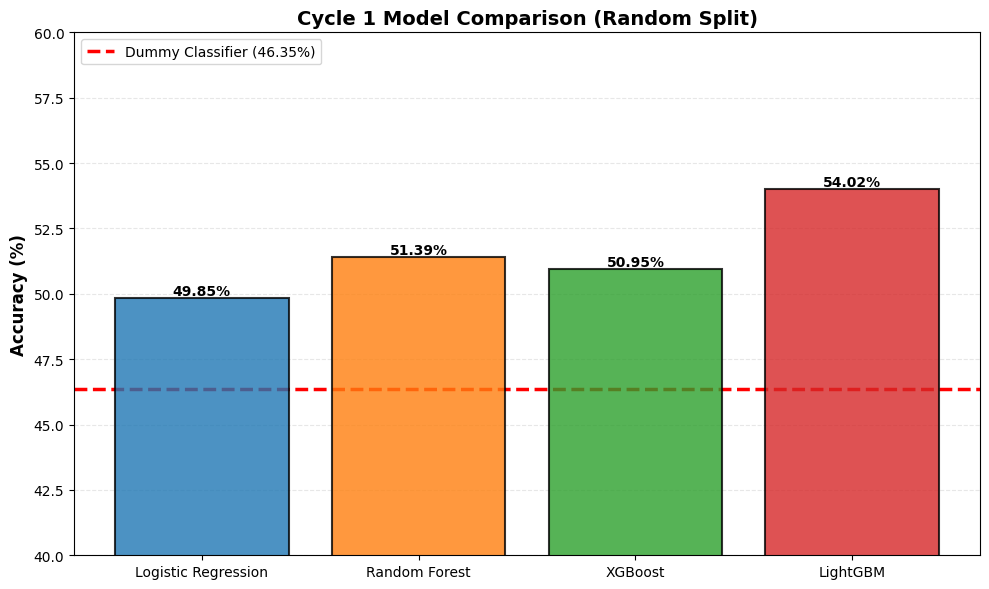

Chart saved as cycle1_model_comparison.png


In [46]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(10, 6))

models = results_d1['Model'].values
accuracies = results_d1['Accuracy %'].values


dummy_acc = accuracies[0]
ax.axhline(y=dummy_acc, color='red', linestyle='--', linewidth=2.5, label=f'Dummy Classifier ({dummy_acc:.2f}%)', zorder=1)


model_names = models[1:]
model_accs = accuracies[1:]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(model_names, model_accs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5, zorder=2)


for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Cycle 1 Model Comparison (Random Split)', fontsize=14, fontweight='bold')
ax.set_ylim(40, 60)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('../../docs/cycle1_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Chart saved as cycle1_model_comparison.png')

### Observations
- **LightGBM is the best untuned model at 54.02%**
- All five models beat the dummy by 4.6–7.68pp, confirming the features carry real predictive signal.